# EE 446 TinyML — Lab 3  
## Quantization of a DNN Using the UCI Human Activity Recognition Dataset

This is the **student version** of the lab notebook.

Complete all code cells marked with **TODO**.  
Use clear variable names and keep the overall notebook structure unchanged.


## 1. Environment Setup

Use the `Python (tinyml-arduino)` Jupyter kernel for this notebook.
All required packages are expected to be preinstalled in the course environment.


In [1]:
import sys
#!{sys.executable} -m pip install -q "tensorflow==2.15.1" "tensorflow-model-optimization==0.8.0" "scikit-learn==1.4.2" "pandas==2.2.2" "matplotlib==3.8.4"


## 2. Imports and Reproducibility


In [2]:
import os
import zipfile
import pathlib
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_model_optimization as tfmot

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)


2026-04-20 10:54:51.686943: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-20 10:54:51.688867: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-20 10:54:51.714769: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-20 10:54:51.714809: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-20 10:54:51.714828: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to regi

TensorFlow version: 2.14.1
TF-MOT version: 0.8.0


## 3. Download and Extract the UCI HAR Dataset

The original dataset contains:
- **561 numerical features** extracted from smartphone sensor signals
- **6 activity classes**
- predefined **training** and **test** splits

The code below downloads and extracts the dataset if it is not already present.


In [3]:
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = "uci_har_dataset.zip"
extract_dir = "."

if not os.path.exists("UCI HAR Dataset"):
    !wget -q "{dataset_url}" -O "{zip_path}"
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    print("Dataset downloaded and extracted.")
else:
    print("Dataset directory already exists.")


Dataset directory already exists.


## 4. Load the Data


In [5]:
def load_har_data(root_dir="UCI HAR Dataset"):
    X_train = np.loadtxt(os.path.join(root_dir, "train", "X_train.txt"))
    y_train = np.loadtxt(os.path.join(root_dir, "train", "y_train.txt")).astype(int) - 1

    X_test = np.loadtxt(os.path.join(root_dir, "test", "X_test.txt"))
    y_test = np.loadtxt(os.path.join(root_dir, "test", "y_test.txt")).astype(int) - 1

    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = load_har_data()

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]
num_features = X_train.shape[1]
num_classes = len(np.unique(y_train))

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("Number of input features:", num_features)
print("Number of classes:", num_classes)

X_train shape: (7352, 561)
X_test shape : (2947, 561)
Number of input features: 561
Number of classes: 6


## 5. Quick Inspection


In [6]:
# TODO:
# Create a small summary table showing the class index, class name, and number of training samples.

label_counts = pd.Series(y_train).value_counts().sort_index()
summary_df = pd.DataFrame({
    "Class Index": range(num_classes),
    "Class Name": class_names,
    "Training Samples": label_counts.values
})
summary_df


,Class Index,Class Name,Training Samples
0,0,WALKING,1226
1,1,WALKING_UPSTAIRS,1073
2,2,WALKING_DOWNSTAIRS,986
3,3,SITTING,1286
4,4,STANDING,1374
5,5,LAYING,1407


## 6. Train a Baseline DNN

We will use a compact dense neural network that is appropriate for a numerical-feature TinyML-style workflow.

### Architecture
- Input: 561 features
- Dense(256, ReLU)
- Dense(128, ReLU)
- Dense(64, ReLU)
- Dense(6, Softmax)


In [9]:
def build_baseline_model(input_dim, num_classes):
    # TODO:
    # Build and compile a DNN with the following architecture:
    # Input -> Dense(256, relu) -> Dense(128, relu) -> Dense(64, relu) -> Dense(num_classes, softmax)
    # Use Adam with learning rate 1e-3.
    # Use sparse_categorical_crossentropy as the loss.
    # Track accuracy as a metric.

    model = tf.keras.Sequential([
            tf.keras.layers.Dense(256,activation = 'relu' , input_shape =(input_dim,)),
            tf.keras.layers.Dense(128,activation = 'relu'),
            tf.keras.layers.Dense(64,activation = 'relu'),
            tf.keras.layers.Dense(num_classes,activation = 'softmax')
    ])
    model.compile(
           optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
           loss='sparse_categorical_crossentropy',
           metrics=['accuracy']
       )
    return model

baseline_model = build_baseline_model(num_features, num_classes)
baseline_model.summary()


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_4 (Dense)             (None, 256)               143872    
                                                                 
 dense_5 (Dense)             (None, 128)               32896     
                                                                 
 dense_6 (Dense)             (None, 64)                8256      
                                                                 
 dense_7 (Dense)             (None, 6)                 390       
                                                                 
Total params: 185414 (724.27 KB)
Trainable params: 185414 (724.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Train the Baseline Model


In [10]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

# TODO:
# Train the baseline model using:
# - validation_split=0.2
# - epochs=40
# - batch_size=64
# - callbacks=callbacks

# <-- Enter your code here <--#
history = baseline_model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=40,
        batch_size=64,
        callbacks=callbacks
)

Epoch 1/40
92/92 [==============================] - 1s 8ms/step - loss: 0.4751 - accuracy: 0.8067 - val_loss: 0.2226 - val_accuracy: 0.9218
Epoch 2/40
92/92 [==============================] - 1s 6ms/step - loss: 0.1763 - accuracy: 0.9340 - val_loss: 0.1587 - val_accuracy: 0.9293
Epoch 3/40
92/92 [==============================] - 1s 6ms/step - loss: 0.1155 - accuracy: 0.9544 - val_loss: 0.4449 - val_accuracy: 0.8736
Epoch 4/40
92/92 [==============================] - 1s 7ms/step - loss: 0.0986 - accuracy: 0.9599 - val_loss: 0.1889 - val_accuracy: 0.9313
Epoch 5/40
92/92 [==============================] - 1s 7ms/step - loss: 0.0879 - accuracy: 0.9667 - val_loss: 0.2582 - val_accuracy: 0.9143
Epoch 6/40
92/92 [==============================] - 1s 6ms/step - loss: 0.0680 - accuracy: 0.9731 - val_loss: 0.2042 - val_accuracy: 0.9307
Epoch 7/40
92/92 [==============================] - 1s 6ms/step - loss: 0.0803 - accuracy: 0.9689 - val_loss: 0.1384 - val_accuracy: 0.9395
Epoch 8/40
92/92 [==

### Training Curves


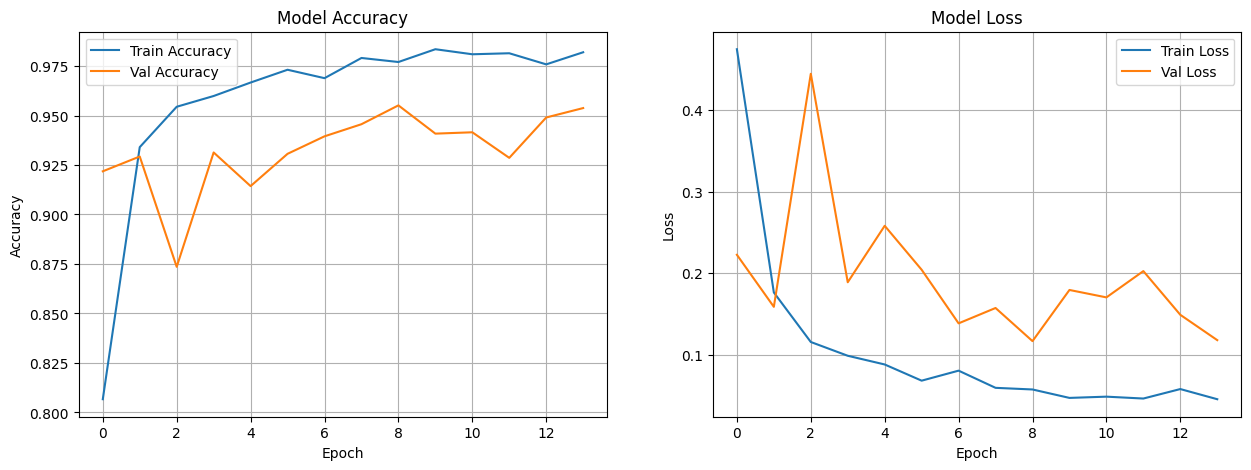

In [14]:
# TODO:
# Plot the training and validation accuracy.
# Plot the training and validation loss.

# <-- Enter your code here <--#
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(15,5))

#Accuracy plot
ax1.plot(history.history['accuracy'], label ='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label ='Val Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

#LOss plot
ax2.plot(history.history['loss'], label ='Train Loss')
ax2.plot(history.history['val_loss'], label ='Val Loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

## 7. Evaluate the Baseline Keras Model


93/93 [==============================] - 0s 2ms/step
Test ccuracy:  0.9311

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.96      0.95       496
           1       0.94      0.90      0.92       471
           2       0.92      0.93      0.93       420
           3       0.94      0.88      0.91       491
           4       0.86      0.95      0.91       532
           5       1.00      0.96      0.98       537

    accuracy                           0.93      2947
   macro avg       0.93      0.93      0.93      2947
weighted avg       0.93      0.93      0.93      2947



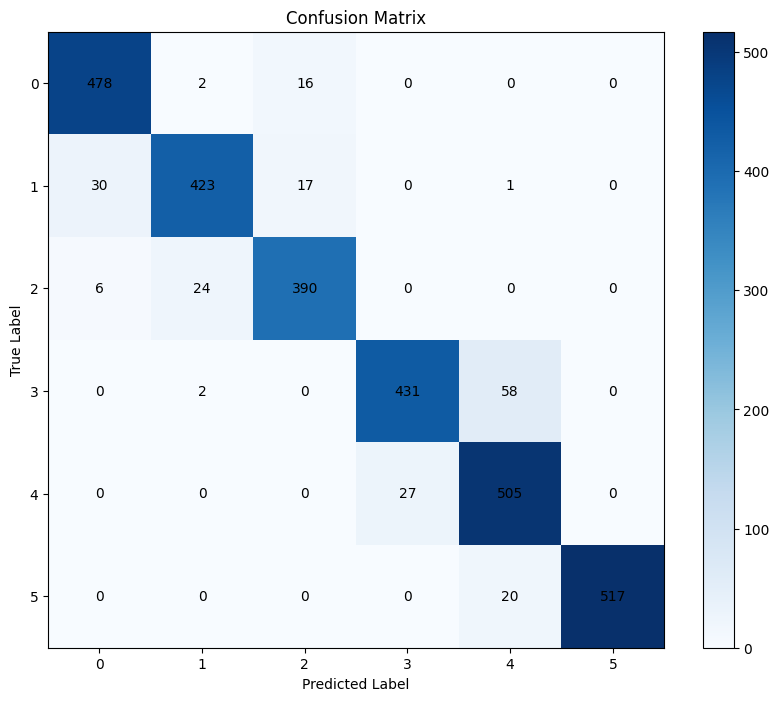

In [20]:
# TODO:
# 1. Obtain predicted probabilities on X_test
# 2. Convert them to class predictions using argmax
# 3. Compute test accuracy
# 4. Print the classification report
# 5. Plot the confusion matrix

# <-- Enter your code here <--#

y_prob = baseline_model.predict(X_test)
y_pred = np.argmax(y_prob,axis=1)
test_accuracy = np.mean(y_pred==y_test)
print(f"Test ccuracy: {test_accuracy: .4f}")
print("\nClassification Report:")
print(classification_report(y_test,y_pred))
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
plt.imshow(cm, cmap='Blues')
plt.colorbar()

# Adding number annotations 
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center', color='black')

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## 8. TensorFlow Lite Utilities

The following helper functions are used to:
- convert Keras models to TensorFlow Lite,
- evaluate TensorFlow Lite models on the test set, and
- measure model file size.


In [33]:
def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def representative_dataset_gen():
    # TODO:
    # Yield 300 representative samples from X_train as float32 tensors.
    # Each yielded item should be in the form: [sample]

    # <-- Enter your code here <--#
    for i in range(300):
        sample = X_train[i:i+1].astype(np.float32)
        yield [sample]
    #raise NotImplementedError("Complete the representative dataset generator.")

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        # TODO:
        # Quantize the input only when the input dtype is int8 or uint8.
        # Otherwise keep the input in the required floating-point dtype.

        # <-- Enter your code here <--#
        if input_details["dtype"] in [np.int8, np.uint8]:
            x = (x/input_scale + input_zero_point).astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        # TODO:
        # If the output is quantized, dequantize it back to float32.
        # <-- Enter your code here <--#
        if output_details["dtype"] in [np.int8 , np.uint8]:
            output= (output.astype(np.float32) - output_zero_point)*output_scale

        y_pred.append(np.argmax(output, axis=1)[0])

    y_pred = np.array(y_pred)
    acc = accuracy_score(y_true, y_pred)
    return acc, y_pred

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO: return the converted FP32 TensorFlow Lite model
    # <-- Enter your code here <--#
    return converter.convert()

def convert_to_tflite_dynamic_range(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization and return the converted model.

    # <-- Enter your code here <--#
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    return converter.convert()

def convert_to_tflite_float16(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization
    # Set supported_types to [tf.float16]
    # Return the converted model

      # <-- Enter your code here <--#
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.target_spec.supported_types = [tf.float16]
    return converter.convert()

  

def convert_to_tflite_int8(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization
    # Attach representative_dataset_gen
    # Restrict to TFLITE_BUILTINS_INT8
    # Set inference_input_type and inference_output_type to tf.int8
    # Return the converted model

    # <-- Enter your code here <--#
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = lambda: representative_dataset_gen()
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8
    return converter.convert()  


## 9. Post-Training Quantization (PTQ)


In [34]:
# TODO:
# Convert the baseline model into:
# - FP32 TFLite
# - dynamic range TFLite
# - float16 TFLite
# - int8 TFLite

# Save each model to disk and record its size in KB.
# Evaluate each TFLite model on the test set.

# <-- Enter your code here <--#

tflite_fp32    = convert_to_tflite_fp32(baseline_model)
tflite_dynamic = convert_to_tflite_dynamic_range(baseline_model)
tflite_fp16    = convert_to_tflite_float16(baseline_model)
tflite_int8    = convert_to_tflite_int8(baseline_model)

size_fp32    = save_binary_model(tflite_fp32,    "model_fp32.tflite")
size_dynamic = save_binary_model(tflite_dynamic, "model_dynamic.tflite")
size_fp16    = save_binary_model(tflite_fp16,    "model_fp16.tflite")
size_int8    = save_binary_model(tflite_int8,    "model_int8.tflite")

acc_fp32,    pred_fp32    = evaluate_tflite_model(tflite_fp32,    X_test, y_test)
acc_dynamic, pred_dynamic = evaluate_tflite_model(tflite_dynamic, X_test, y_test)
acc_fp16,    pred_fp16    = evaluate_tflite_model(tflite_fp16,    X_test, y_test)
acc_int8,    pred_int8    = evaluate_tflite_model(tflite_int8,    X_test, y_test)


INFO:tensorflow:Assets written to: /tmp/tmpelsvetoa/assets


INFO:tensorflow:Assets written to: /tmp/tmpelsvetoa/assets
2026-04-20 11:52:31.105611: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-20 11:52:31.105663: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-20 11:52:31.105784: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpelsvetoa
2026-04-20 11:52:31.106644: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-20 11:52:31.106657: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpelsvetoa
2026-04-20 11:52:31.109128: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-20 11:52:31.144552: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpelsvetoa
2026-04-20 11:52:31.152877: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

INFO:tensorflow:Assets written to: /tmp/tmpbk1qmjqp/assets


INFO:tensorflow:Assets written to: /tmp/tmpbk1qmjqp/assets
2026-04-20 11:52:31.663212: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-20 11:52:31.663271: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-20 11:52:31.663405: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpbk1qmjqp
2026-04-20 11:52:31.663959: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-20 11:52:31.663970: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpbk1qmjqp
2026-04-20 11:52:31.666225: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-20 11:52:31.698586: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpbk1qmjqp
2026-04-20 11:52:31.706949: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

INFO:tensorflow:Assets written to: /tmp/tmpfc4m7p6j/assets


INFO:tensorflow:Assets written to: /tmp/tmpfc4m7p6j/assets
2026-04-20 11:52:32.531435: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-20 11:52:32.531492: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-20 11:52:32.531617: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpfc4m7p6j
2026-04-20 11:52:32.532423: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-20 11:52:32.532439: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpfc4m7p6j
2026-04-20 11:52:32.534543: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-20 11:52:32.567703: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpfc4m7p6j
2026-04-20 11:52:32.576399: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

INFO:tensorflow:Assets written to: /tmp/tmp7zcy6n0w/assets


INFO:tensorflow:Assets written to: /tmp/tmp7zcy6n0w/assets
/home/wadhwa19/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-04-20 11:52:33.051580: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-20 11:52:33.051630: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-20 11:52:33.051769: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp7zcy6n0w
2026-04-20 11:52:33.052634: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-20 11:52:33.052652: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp7zcy6n0w
2026-04-20 11:52:33.054892: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.


## 10. PTQ Comparison: Accuracy and Model Size


In [56]:
# TODO:
# Create a comparison DataFrame containing:
# Model Family, Format, Test Accuracy, Model Size (KB)

# <-- Enter your code here <--#
baseline_model.save("baseline_model.keras")
comparison_df = pd.DataFrame([
    {
        "Model Family": "Baseline DNN",
        "Format":       "FP32 (Keras)",
        "Test Accuracy": test_accuracy,
        "Model Size (KB)": os.path.getsize("baseline_model.keras") / 1024.0
        if os.path.exists("baseline_model.keras") else None
    },
    {
        "Model Family": "Baseline DNN",
        "Format":       "TFLite FP32",
        "Test Accuracy": acc_fp32,
        "Model Size (KB)": size_fp32
    },
    {
        "Model Family": "Baseline DNN",
        "Format":       "TFLite Dynamic Range",
        "Test Accuracy": acc_dynamic,
        "Model Size (KB)": size_dynamic
    },
    {
        "Model Family": "Baseline DNN",
        "Format":       "TFLite Float16",
        "Test Accuracy": acc_fp16,
        "Model Size (KB)": size_fp16
    },
    {
        "Model Family": "Baseline DNN",
        "Format":       "TFLite INT8",
        "Test Accuracy": acc_int8,
        "Model Size (KB)": size_int8
    },
])


comparison_df["Test Accuracy"]    = comparison_df["Test Accuracy"].round(4)
comparison_df["Model Size (KB)"]  = comparison_df["Model Size (KB)"].round(2)
print(comparison_df.to_string(index=False, col_space=30))

                  Model Family                         Format                  Test Accuracy                Model Size (KB)
                  Baseline DNN                   FP32 (Keras)                         0.9311                        2203.17
                  Baseline DNN                    TFLite FP32                         0.9311                         726.76
                  Baseline DNN           TFLite Dynamic Range                         0.9318                         186.16
                  Baseline DNN                 TFLite Float16                         0.9311                         365.79
                  Baseline DNN                    TFLite INT8                         0.9315                         185.36


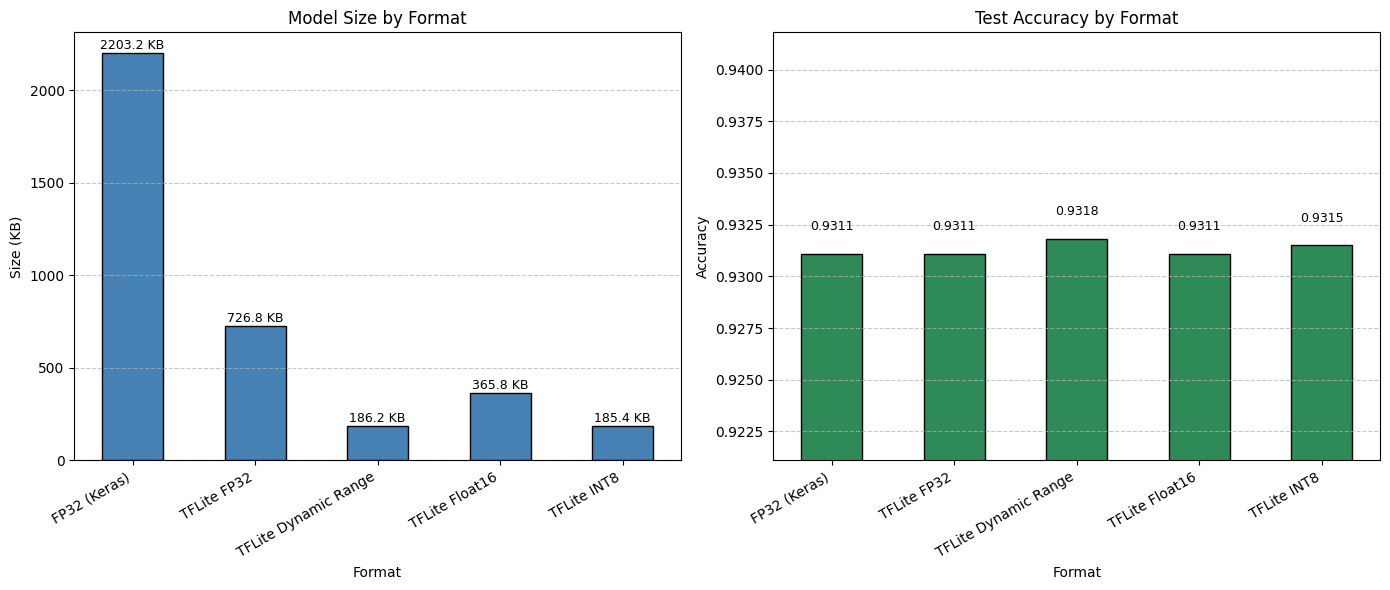

In [57]:
# TODO:
# Create one bar plot for model size and another for test accuracy.

# <-- Enter your code here <--#
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

formats = comparison_df["Format"]
x = range(len(formats))
ax1.bar(x, comparison_df["Model Size (KB)"], color='steelblue', edgecolor='black', width=0.5)
ax1.set_xticks(x)
ax1.set_xticklabels(formats, rotation=30, ha='right')
ax1.set_title('Model Size by Format')
ax1.set_ylabel('Size (KB)')
ax1.set_xlabel('Format')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

for i, val in enumerate(comparison_df["Model Size (KB)"]):
    ax1.text(i, val + 5, f"{val:.1f} KB", ha='center', va='bottom', fontsize=9)


ax2.bar(x, comparison_df["Test Accuracy"], color='seagreen', edgecolor='black', width=0.5)
ax2.set_xticks(x)
ax2.set_xticklabels(formats, rotation=30, ha='right')
ax2.set_title('Test Accuracy by Format')
ax2.set_ylabel('Accuracy')
ax2.set_xlabel('Format')
ax2.set_ylim(
    comparison_df["Test Accuracy"].min() - 0.01,
    comparison_df["Test Accuracy"].max() + 0.01
)
ax2.grid(axis='y', linestyle='--', alpha=0.7)

for i, val in enumerate(comparison_df["Test Accuracy"]):
    ax2.text(i, val + 0.001, f"{val:.4f}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


### Confusion Matrix for the PTQ Int8 Model


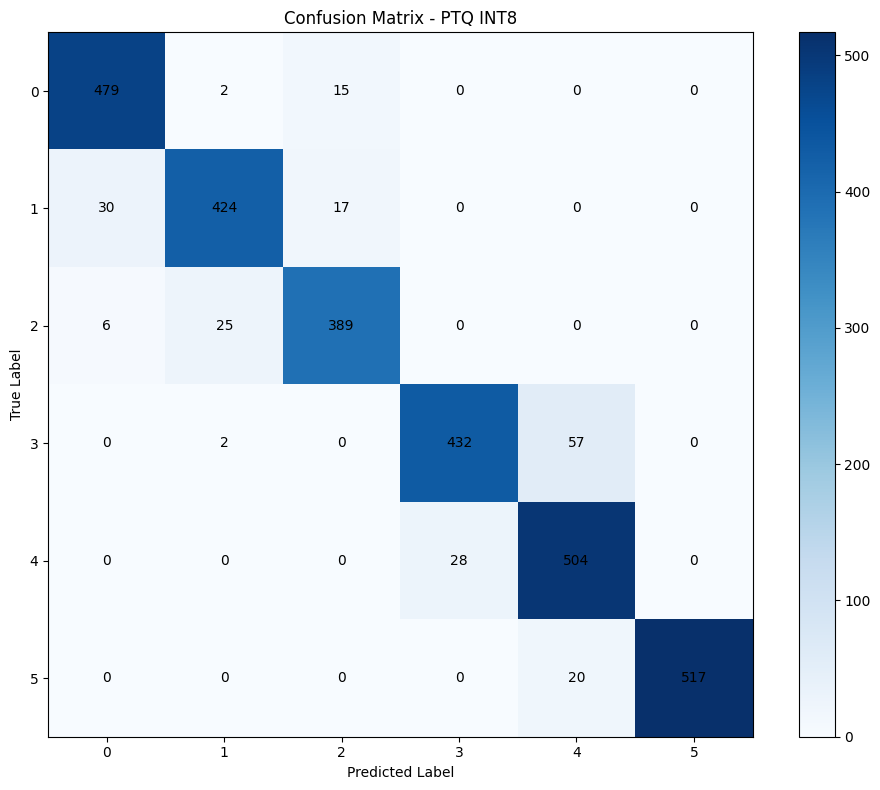

Classification Report - PTQ INT8:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95       496
           1       0.94      0.90      0.92       471
           2       0.92      0.93      0.93       420
           3       0.94      0.88      0.91       491
           4       0.87      0.95      0.91       532
           5       1.00      0.96      0.98       537

    accuracy                           0.93      2947
   macro avg       0.93      0.93      0.93      2947
weighted avg       0.93      0.93      0.93      2947



In [46]:
# TODO:
# Plot the confusion matrix for the PTQ int8 model.
# Print the classification report for the PTQ int8 model.

# <-- Enter your code here <--#

cm_int8 = confusion_matrix(y_test, pred_int8)

plt.figure(figsize=(10, 8))
plt.imshow(cm_int8, cmap='Blues')
plt.colorbar()

for i in range(cm_int8.shape[0]):
    for j in range(cm_int8.shape[1]):
        plt.text(j, i, str(cm_int8[i, j]), ha='center', va='center', color='black')

plt.title('Confusion Matrix - PTQ INT8')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(range(num_classes))
plt.yticks(range(num_classes))
plt.tight_layout()
plt.show()


print("Classification Report - PTQ INT8:")
print(classification_report(y_test, pred_int8))

## 11. Quantization-Aware Training (QAT)

QAT simulates quantization effects during training so that the final model is usually more robust after conversion to int8.


In [47]:
# TODO:
# Create a QAT model from the trained baseline model using TF-MOT.
# Compile it with Adam(1e-4), sparse_categorical_crossentropy, and accuracy.

# <-- Enter your code here <--#
qat_model = tfmot.quantization.keras.quantize_model(baseline_model)

qat_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

qat_model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 quantize_layer (QuantizeLa  (None, 561)               3         
 yer)                                                            
                                                                 
 quant_dense_4 (QuantizeWra  (None, 256)               143877    
 pperV2)                                                         
                                                                 
 quant_dense_5 (QuantizeWra  (None, 128)               32901     
 pperV2)                                                         
                                                                 
 quant_dense_6 (QuantizeWra  (None, 64)                8261      
 pperV2)                                                         
                                                                 
 quant_dense_7 (QuantizeWra  (None, 6)                

### Fine-Tune the QAT Model


In [48]:
# TODO:
# Fine-tune the QAT model for 8 epochs using validation_split=0.2 and batch_size=64.

# <-- Enter your code here <--#
qat_history = qat_model.fit(
    X_train, y_train,
    epochs=8,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/8
92/92 [==============================] - 2s 10ms/step - loss: 0.0629 - accuracy: 0.9855 - val_loss: 0.1221 - val_accuracy: 0.9531
Epoch 2/8
92/92 [==============================] - 1s 9ms/step - loss: 0.0392 - accuracy: 0.9888 - val_loss: 0.1274 - val_accuracy: 0.9517
Epoch 3/8
92/92 [==============================] - 1s 8ms/step - loss: 0.0373 - accuracy: 0.9876 - val_loss: 0.1298 - val_accuracy: 0.9524
Epoch 4/8
92/92 [==============================] - 1s 8ms/step - loss: 0.0332 - accuracy: 0.9891 - val_loss: 0.1273 - val_accuracy: 0.9517
Epoch 5/8
92/92 [==============================] - 1s 7ms/step - loss: 0.0319 - accuracy: 0.9896 - val_loss: 0.1671 - val_accuracy: 0.9436
Epoch 6/8
92/92 [==============================] - 1s 8ms/step - loss: 0.0318 - accuracy: 0.9884 - val_loss: 0.1546 - val_accuracy: 0.9483
Epoch 7/8
92/92 [==============================] - 1s 7ms/step - loss: 0.0311 - accuracy: 0.9896 - val_loss: 0.1355 - val_accuracy: 0.9490
Epoch 8/8
92/92 [=========

### Evaluate the QAT Keras Model


In [49]:
# TODO:
# Evaluate the QAT Keras model on X_test.
# Print the test accuracy and classification report.

# <-- Enter your code here <--#

qat_loss, qat_accuracy = qat_model.evaluate(X_test, y_test, verbose=0)
print(f"QAT Test Accuracy: {qat_accuracy:.4f}")
qat_pred = np.argmax(qat_model.predict(X_test), axis=1)
print("\nClassification Report - QAT Keras:")
print(classification_report(y_test, qat_pred))

QAT Test Accuracy: 0.9332
93/93 [==============================] - 0s 3ms/step

Classification Report - QAT Keras:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95       496
           1       0.94      0.90      0.92       471
           2       0.94      0.94      0.94       420
           3       0.96      0.86      0.91       491
           4       0.85      0.97      0.91       532
           5       1.00      0.96      0.98       537

    accuracy                           0.93      2947
   macro avg       0.94      0.93      0.93      2947
weighted avg       0.94      0.93      0.93      2947



### Convert the QAT Model to Int8 TensorFlow Lite


In [50]:
# TODO:
# Convert the QAT model to int8 TensorFlow Lite.
# Save the model, compute its size, and evaluate it on the test set.

# <-- Enter your code here <--#

converter = tf.lite.TFLiteConverter.from_keras_model(qat_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = tf.lite.RepresentativeDataset(representative_dataset_gen)
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8
tflite_qat_int8 = converter.convert()

size_qat_int8 = save_binary_model(tflite_qat_int8, "model_qat_int8.tflite")
acc_qat_int8, pred_qat_int8 = evaluate_tflite_model(tflite_qat_int8, X_test, y_test)


print(f"QAT INT8 Model Size : {size_qat_int8:.2f} KB")
print(f"QAT INT8 Accuracy   : {acc_qat_int8:.4f}")


print("\n--- Full Comparison ---")
print(f"Baseline FP32       : {test_accuracy:.4f}")
print(f"PTQ Dynamic Range   : {acc_dynamic:.4f}")
print(f"PTQ Float16         : {acc_fp16:.4f}")
print(f"PTQ INT8            : {acc_int8:.4f}")
print(f"QAT Keras           : {qat_accuracy:.4f}")
print(f"QAT INT8 TFLite     : {acc_qat_int8:.4f}")


INFO:tensorflow:Assets written to: /tmp/tmpw5rmu98q/assets


INFO:tensorflow:Assets written to: /tmp/tmpw5rmu98q/assets


QAT INT8 Model Size : 185.78 KB
QAT INT8 Accuracy   : 0.9328

--- Full Comparison ---
Baseline FP32       : 0.9311
PTQ Dynamic Range   : 0.9318
PTQ Float16         : 0.9311
PTQ INT8            : 0.9315
QAT Keras           : 0.9332
QAT INT8 TFLite     : 0.9328


/home/wadhwa19/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-04-20 12:05:31.747214: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-20 12:05:31.747263: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-20 12:05:31.747400: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpw5rmu98q
2026-04-20 12:05:31.749583: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-20 12:05:31.749614: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpw5rmu98q
2026-04-20 12:05:31.755950: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-20 12:05:31.806328: I tensorflow/cc/saved_model/loa

## 12. PTQ Int8 vs QAT Int8


In [53]:
# TODO:
# Create a DataFrame comparing PTQ int8 and QAT int8:
# Model, Test Accuracy, Model Size (KB)

# <-- Enter your code here <--#
# <-- Enter your code here <--#
comparison2_df = pd.DataFrame([
    {
        "Model":            "PTQ INT8",
        "Test Accuracy":    acc_int8,
        "Model Size (KB)":  size_int8
    },
    {
        "Model":            "QAT INT8",
        "Test Accuracy":    acc_qat_int8,
        "Model Size (KB)":  size_qat_int8
    }
])

comparison2_df["Test Accuracy"]   = comparison2_df["Test Accuracy"].round(4)
comparison2_df["Model Size (KB)"] = comparison2_df["Model Size (KB)"].round(2)

# Add accuracy difference row
acc_diff  = acc_qat_int8 - acc_int8
size_diff = size_qat_int8 - size_int8

print(comparison2_df.to_string(index=False))
print("-" * 45)
print(f"  Accuracy gain (QAT over PTQ) : {acc_diff:+.4f}")
print(f"  Size difference              : {size_diff:+.2f} KB")

   Model  Test Accuracy  Model Size (KB)
PTQ INT8         0.9315           185.36
QAT INT8         0.9328           185.78
---------------------------------------------
  Accuracy gain (QAT over PTQ) : +0.0014
  Size difference              : +0.42 KB


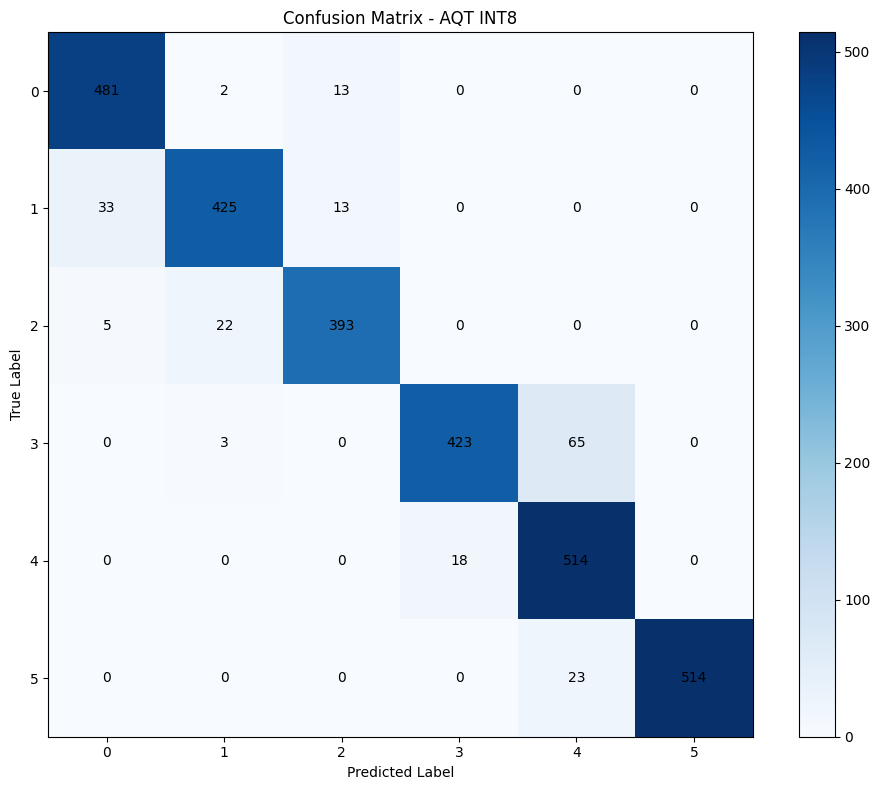

In [52]:
# TODO:
# Plot the confusion matrix for the QAT int8 model.
cm_int8_qa = confusion_matrix(y_test, qat_pred)

plt.figure(figsize=(10, 8))
plt.imshow(cm_int8_qa, cmap='Blues')
plt.colorbar()

for i in range(cm_int8_qa.shape[0]):
    for j in range(cm_int8_qa.shape[1]):
        plt.text(j, i, str(cm_int8_qa[i, j]), ha='center', va='center', color='black')

plt.title('Confusion Matrix - AQT INT8')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(range(num_classes))
plt.yticks(range(num_classes))
plt.tight_layout()
plt.show()




## 13. Summary Questions

Write short answers to the following:
1. Which quantization method gave the smallest model size?
2. Which quantization method gave the best accuracy among the TensorFlow Lite models?
3. Did QAT improve the final int8 model compared with PTQ int8?
4. Why is this dataset a good fit for a DNN-based TinyML workflow?
5. If you were deploying this model on a resource-constrained device, which version would you choose and why?


#### A1.
Baseline DNN to TFLite INT8 was 185.36KB which was the smallest model.

#### A2.
Baseline DNN to TFLite Dynamic Range was 93.18%  which was the highest among all methods
#### A3.
Yes, the accuracy improved by  +0.0014 when quatization aware training was done on INT8.
#### A4.
After initial training the model size was reduced by almost 4 times without a lot of accuracy loss. Additionally, the data required no preprocessing and extensive cnn making it feasible for tinyML.
#### A5
As the QAT INT8 model has the lowest accuracy drop and smallest model size, I would deply that model. Moreover, QAT incorporates for error in quantisation whule training making it more robust to loss of features.

## 14. Submission Requirements

Submit the following:
- your completed notebook,
- the generated `.tflite` files,
- screenshots or output cells showing the final comparison table,
- confusion matrices for the baseline model and the final int8 model you want to highlight,
- and short written observations answering the summary questions.

Make sure your notebook runs from top to bottom without errors.
